## 사용 데이터
- 2024.08 ~ 2025.10 서울특별시 월세 실거래가 데이터
- 한국은행 기준금리(환산보증금을 계산하기 위함)
- 시장 및 대출금리

    | 컬럼명              | 한 줄 요약                                              |
    | ------------------- | -------------------------------------------------------- |
    | 소비자물가          | 물가가 얼마나 올랐는지 보여주는 지표. 물가↑ → 월세 인상 압력↑ |
    | KORIBOR             | 은행끼리 돈을 빌릴 때 적용하는 기준 금리. 시장 기준금리 역할 |
    | 기업대출            | 기업이 대출받을 때 적용되는 금리. 경기 흐름을 반영하는 간접 지표 |
    | 전세자금대출        | 세입자가 전세 계약 시 부담하는 대출 금리. 전세 부담↑ → 월세 수요↑ |
    | CD                  | 은행 예금·대출의 기준이 되는 금리. 전세보다 월세 선호를 높이는 요인 |
    | 무담보콜금리        | 은행 간 초단기 자금 거래 금리. 금융시장 단기 유동성 지표 |
    | 변동형주택담보대출  | 주택담보대출의 변동금리. 집주인 이자 부담↑ → 월세·보증금 인상 압력 |



## 라이브러리 임포트 및 데이터 로드

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    mean_absolute_percentage_error,
)

from xgboost import XGBRegressor
from lightgbm import LGBMRegressor


sns.set(style="whitegrid", font="Malgun Gothic")  # 윈도우 한글 폰트
plt.rcParams["axes.unicode_minus"] = False        # 마이너스 깨짐 방지

# notebooks/ 기준으로 상위 폴더의 data 디렉터리 사용
BASE_DIR = Path().resolve().parent / "data"

train_path = BASE_DIR / "월세_train(24.01~25.08).csv"
test_path  = BASE_DIR / "월세_test(25.09~25.10).csv"

train = pd.read_csv(train_path, encoding="utf-8-sig")
test  = pd.read_csv(test_path,  encoding="utf-8-sig")

print("train:", train.shape)
print("test :", test.shape)
train.head()


train: (618550, 17)
test : (74617, 17)


,자치구명,법정동명,층,연월,임대면적,보증금(만원),임대료(만원),건축년도,건물용도,소비자물가,무담보콜금리,KORIBOR,CD,기업대출,전세자금대출,변동형주택담보대출,기준금리
0,마포구,노고산동,5.0,2024-12,31.12,8000,50,1998.0,오피스텔,1.9,3.055,3.31,3.35,4.62,4.34,4.32,3.00
1,관악구,신림동,0.0,2024-10,50.00,27000,15,2024.0,단독다가구,1.3,3.321,3.43,3.43,4.71,4.26,4.14,3.50
2,중랑구,면목동,0.0,2024-10,50.00,3000,90,2018.0,단독다가구,1.3,3.321,3.43,3.43,4.71,4.26,4.14,3.50
3,종로구,명륜3가,2.0,2024-09,20.96,500,76,1996.0,연립다세대,1.6,3.529,3.49,3.52,4.77,4.05,4.08,3.50
4,강서구,공항동,0.0,2024-11,46.98,1000,60,2002.0,단독다가구,1.5,3.245,3.40,3.42,4.76,4.43,4.25,3.25


## 환산보증금_평당가 타깃 생성
> 환산보증금 = (보증금 + (월세*12)) / ((기준금리+2)/100)


In [2]:
TARGET = "환산보증금_평당가"
TARGET_LOG = "log_" + TARGET 

df_train = train.copy()
df_test  = test.copy()

for df in [df_train, df_test]:
    # 안전한 최소 이자율 (0 이하 방지)
    df["적용이자율"] = (df["기준금리"] + 2.0) / 100.0
    df.loc[df["적용이자율"] <= 0, "적용이자율"] = np.nan

    # 환산보증금: 보증금 + 월세를 전세로 환산
    df["환산보증금(만원)"] = (df["보증금(만원)"] + (df["임대료(만원)"] * 12)) / df["적용이자율"]

    # 평수 (임대면적이 ㎡라면 3.3으로 나눔)
    df["전용평수"] = df["임대면적"] / 3.3

    # 평당 환산보증금 (타깃)
    df[TARGET] = df["환산보증금(만원)"] / df["전용평수"]

    df[TARGET_LOG] = np.log1p(df[TARGET])

    # 연월에서 연도/월 분리
    df["계약연도"] = df["연월"].str.slice(0, 4).astype(int)
    df["계약월"]   = df["연월"].str.slice(5, 7).astype(int)

    # # 계약월은 범주형으로 취급
    # df["계약월"] = df["계약월"].astype("category")

    # 건물 연식 계산
    df["건물연식"] = df["계약연도"] - df["건축년도"]

    # df["평균금리"] = df[["CD", "전세자금대출", "변동형주택담보대출"]].mean(axis=1)

    # # 1) 층 구간 (부동산 시장 관행)
    # def get_floor_grade(floor):
    #     if floor < 0:
    #         return "지하"  # 큰 할인
    #     elif floor <= 2:
    #         return "저층"  # 습기, 소음, 프라이버시 이슈
    #     elif floor <= 10:
    #         return "중층"  # 가장 선호
    #     else:
    #         return "고층"  # 전망 프리미엄 (but 단독다가구는 없음)

    # df["층_구간"] = df["층"].apply(get_floor_grade)

df_train[[ "보증금(만원)", "임대료(만원)", "기준금리", "적용이자율", "환산보증금(만원)", "전용평수", TARGET]].head()

,보증금(만원),임대료(만원),기준금리,적용이자율,환산보증금(만원),전용평수,환산보증금_평당가
0,8000,50,3.00,0.0500,172000.000000,9.430303,18239.074550
1,27000,15,3.50,0.0550,494181.818182,15.151515,32616.000000
2,3000,90,3.50,0.0550,74181.818182,15.151515,4896.000000
3,500,76,3.50,0.0550,25672.727273,6.351515,4041.984733
4,1000,60,3.25,0.0525,32761.904762,14.236364,2301.283221


In [3]:
print("=== train.info ===")
df_train.info()

=== train.info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 618550 entries, 0 to 618549
Data columns (total 25 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   자치구명           618550 non-null  object 
 1   법정동명           618550 non-null  object 
 2   층              618550 non-null  float64
 3   연월             618550 non-null  object 
 4   임대면적           618550 non-null  float64
 5   보증금(만원)        618550 non-null  int64  
 6   임대료(만원)        618550 non-null  int64  
 7   건축년도           618550 non-null  float64
 8   건물용도           618550 non-null  object 
 9   소비자물가          618550 non-null  float64
 10  무담보콜금리         618550 non-null  float64
 11  KORIBOR        618550 non-null  float64
 12  CD             618550 non-null  float64
 13  기업대출           618550 non-null  float64
 14  전세자금대출         618550 non-null  float64
 15  변동형주택담보대출      618550 non-null  float64
 16  기준금리           618550 non-null  float64
 17  적용이자율     

In [4]:
print("\n=== 결측비율 (train) ===")
df_train.isnull().sum().sort_values(ascending=False).head(20)


=== 결측비율 (train) ===


자치구명         0
법정동명         0
층            0
연월           0
임대면적         0
보증금(만원)      0
임대료(만원)      0
건축년도         0
건물용도         0
소비자물가        0
무담보콜금리       0
KORIBOR      0
CD           0
기업대출         0
전세자금대출       0
변동형주택담보대출    0
기준금리         0
적용이자율        0
환산보증금(만원)    0
전용평수         0
dtype: int64

## EDA

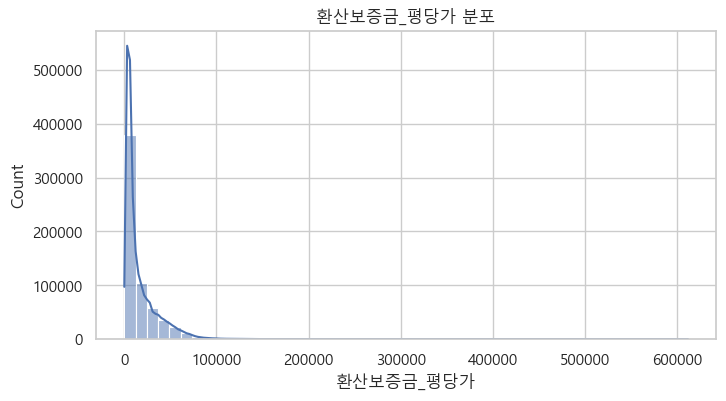

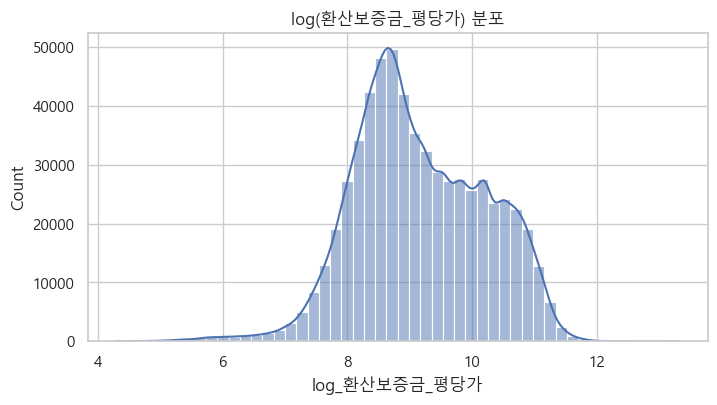

In [5]:
# 타깃 분포
plt.figure(figsize=(8, 4))
sns.histplot(df_train[TARGET].dropna(), bins=50, kde=True)
plt.title("환산보증금_평당가 분포")
plt.show()

# 로그 스케일 분포 (꼬리 완화용)
df_train["log_" + TARGET] = np.log1p(df_train[TARGET])

plt.figure(figsize=(8, 4))
sns.histplot(df_train["log_" + TARGET].dropna(), bins=50, kde=True)
plt.title("log(환산보증금_평당가) 분포")
plt.show()


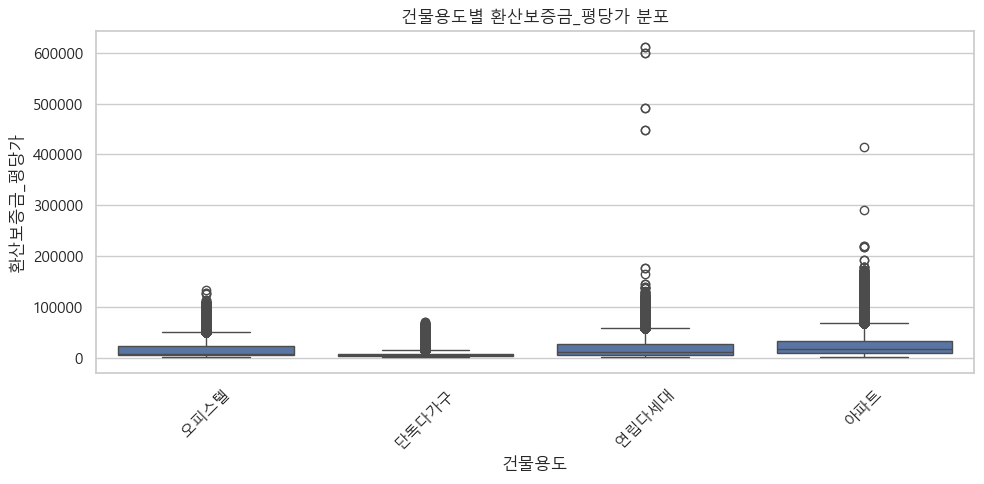

In [6]:
# 건물용도별 평당가
if "건물용도" in df_train.columns:
    plt.figure(figsize=(10, 5))
    sns.boxplot(data=df_train, x="건물용도", y=TARGET)
    plt.xticks(rotation=45)
    plt.title("건물용도별 환산보증금_평당가 분포")
    plt.tight_layout()
    plt.show()

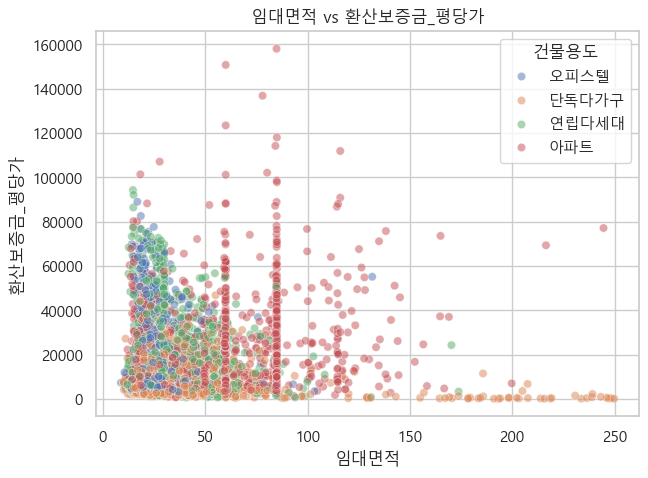

In [7]:
# 임대면적 vs 평당가 (면적이 큰 집일수록 평당가 하락하는지 등)
plt.figure(figsize=(7, 5))
sample = df_train.sample(min(len(df_train), 4000), random_state=42)
sns.scatterplot(data=sample, x="임대면적", y=TARGET, hue="건물용도", alpha=0.5)
plt.title("임대면적 vs 환산보증금_평당가")
plt.show()

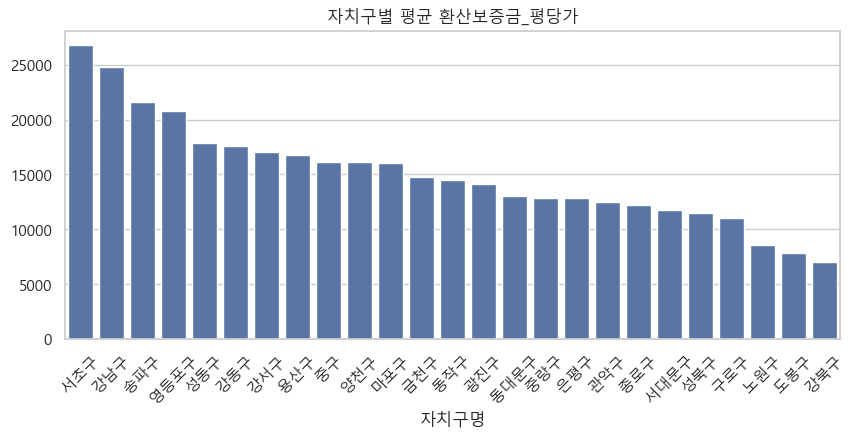

In [8]:
# 자치구별 평균 평당가 (지역 프리미엄)
if {"자치구명", TARGET}.issubset(df_train.columns):
    gu_mean = df_train.groupby("자치구명")[TARGET].mean().sort_values(ascending=False)
    plt.figure(figsize=(10, 4))
    sns.barplot(x=gu_mean.index.astype(str), y=gu_mean.values)
    plt.xticks(rotation=45)
    plt.title("자치구별 평균 환산보증금_평당가")
    plt.show()

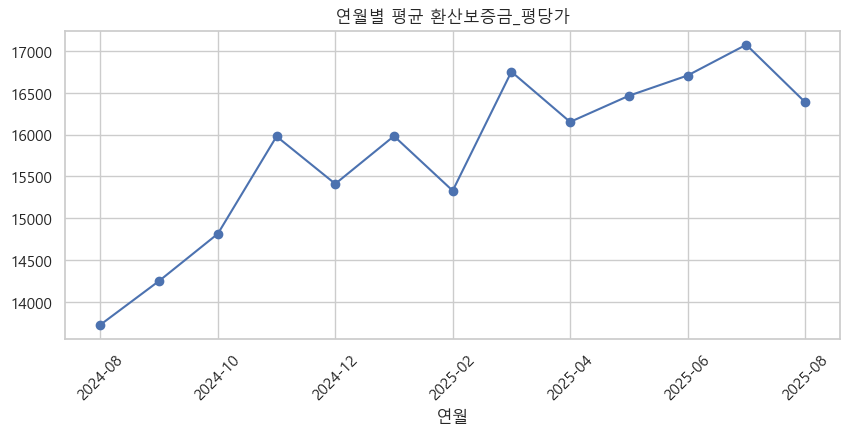

In [9]:
# 시간(연월)에 따른 시세 흐름
if {"연월", TARGET}.issubset(df_train.columns):
    month_mean = df_train.groupby("연월")[TARGET].mean()
    plt.figure(figsize=(10, 4))
    month_mean.plot(marker="o")
    plt.xticks(rotation=45)
    plt.grid(True)
    plt.title("연월별 평균 환산보증금_평당가")
    plt.show()

In [10]:
num_cols = df_train.select_dtypes(include=[np.number]).columns.tolist()
corr = df_train[num_cols].corr()

# 타깃과의 상관계수
target_corr = corr[TARGET].sort_values(ascending=False)
target_corr

환산보증금_평당가        1.000000
log_환산보증금_평당가    0.863262
보증금(만원)          0.756611
환산보증금(만원)        0.747949
층                0.312528
건축년도             0.302078
전용평수             0.106970
임대면적             0.106970
계약연도             0.032834
소비자물가            0.019057
계약월             -0.010218
변동형주택담보대출       -0.011478
임대료(만원)         -0.021553
전세자금대출          -0.022220
기업대출            -0.036729
KORIBOR         -0.038270
CD              -0.038934
적용이자율           -0.041615
기준금리            -0.041615
무담보콜금리          -0.041657
건물연식            -0.300925
Name: 환산보증금_평당가, dtype: float64

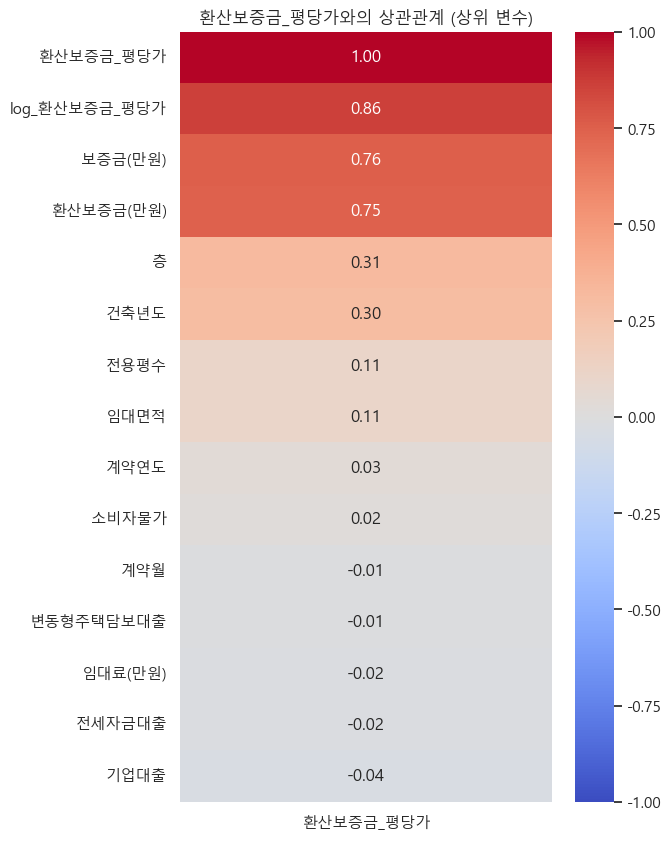

In [11]:
# 타깃과 상관 높은 상위 변수 히트맵
top_n = 15
top_features = target_corr.index[:top_n]

plt.figure(figsize=(6, 10))
sns.heatmap(
    corr.loc[top_features, [TARGET]],
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1
)
plt.title("환산보증금_평당가와의 상관관계 (상위 변수)")
plt.show()

## Features

In [ ]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import TimeSeriesSplit

TARGET = "환산보증금_평당가"
TARGET_LOG = "log_" + TARGET

# 1) 모델링에 쓸 행만 남기기
df_train_ml = df_train.dropna(subset=[TARGET_LOG]).copy()
df_train_ml = df_train_ml.sort_values("연월").reset_index(drop=True)
df_test_ml  = df_test.copy()


# ===================================
# 2) Label Encoding으로 변경
# ===================================
# 2-1) 복합 카테고리 생성
df_train_ml["자치구_건물용도"] = df_train_ml["자치구명"] + "_" + df_train_ml["건물용도"]
df_test_ml["자치구_건물용도"] = df_test_ml["자치구명"] + "_" + df_test_ml["건물용도"]

# 2-2) 각 범주형 컬럼별로 LabelEncoder 적용 (train+test 전체 기준)
cat_cols_for_le = ["자치구명", "법정동명", "자치구_건물용도"]

for col in cat_cols_for_le:
    le = LabelEncoder()
    
    # train과 test를 합쳐서 모든 카테고리로 학습
    all_vals = pd.concat([df_train_ml[col], df_test_ml[col]]).astype(str)
    le.fit(all_vals)
    
    df_train_ml[col + "_LE"] = le.transform(df_train_ml[col].astype(str))
    df_test_ml[col + "_LE"] = le.transform(df_test_ml[col].astype(str))

# ===================================
# 5) 최종 피처 선택
# ===================================
candidate_features = [
    "자치구명_LE", "법정동명_LE",
    "자치구_건물용도_LE", 
    "건물연식",
    "건물용도",
    "층",
    "임대면적",
    "KORIBOR","기업대출","전세자금대출",
    "CD","무담보콜금리",
    "변동형주택담보대출",
    "소비자물가",
    # "계약연도", "계약일",
    # "평균금리",
    # "층_구간"
]

# 실제 존재하는 컬럼만 필터링
candidate_features = [c for c in candidate_features if c in df_train_ml.columns]

# 6) 피처/타깃 분리
X_train_ml = df_train_ml[candidate_features]
y_train_ml = df_train_ml[TARGET_LOG]

X_test_ml = df_test_ml[candidate_features]
y_test_ml = df_test_ml[TARGET_LOG]  # 평가용

print(f"\n✅ Feature Engineering 완료!")
print(f"   - Train: {X_train_ml.shape}")
print(f"   - Test:  {X_test_ml.shape}")
print(f"   - 총 피처 수: {len(candidate_features)}개")
print(f"\n사용된 피처 목록:")
for i, feat in enumerate(candidate_features, 1):
    print(f"   {i:2d}. {feat}")

# 검증: 샘플 데이터 출력
print(f"\n🔍 샘플 데이터 확인 (노원구):")
sample = df_train_ml[df_train_ml["자치구명"] == "노원구"].head(5)
print(sample[["연월", "자치구명", "환산보증금_평당가", "log_환산보증금_평당가", "자치구명_LE"]])


✅ Feature Engineering 완료!
   - Train: (618550, 14)
   - Test:  (74617, 14)
   - 총 피처 수: 14개

사용된 피처 목록:
    1. 자치구명_LE
    2. 법정동명_LE
    3. 자치구_건물용도_LE
    4. 건물연식
    5. 건물용도
    6. 층
    7. 임대면적
    8. KORIBOR
    9. 기업대출
   10. 전세자금대출
   11. CD
   12. 무담보콜금리
   13. 변동형주택담보대출
   14. 소비자물가

🔍 샘플 데이터 확인 (노원구):
          연월 자치구명    환산보증금_평당가  log_환산보증금_평당가  자치구명_LE
0    2024-08  노원구  2639.434407       7.878699        8
27   2024-08  노원구  4620.000000       8.438366        8
197  2024-08  노원구  7161.290323       8.876585        8
272  2024-08  노원구  2760.000000       7.923348        8
300  2024-08  노원구  6528.000000       8.784009        8


In [13]:
tscv = TimeSeriesSplit(n_splits=5)
for i, (tr, va) in enumerate(tscv.split(df_train_ml)):
    print(f"Fold {i}: train max idx = {tr.max()}, val min idx = {va.min()}")

Fold 0: train max idx = 103094, val min idx = 103095
Fold 1: train max idx = 206185, val min idx = 206186
Fold 2: train max idx = 309276, val min idx = 309277
Fold 3: train max idx = 412367, val min idx = 412368
Fold 4: train max idx = 515458, val min idx = 515459


## 전처리 파이프라인 및 모델 정의

In [14]:
# ===================================
# 전처리 파이프라인 및 모델 정의
# ===================================
# 숫자 / 범주 피처 분리 (train 기준)
numeric_features = X_train_ml.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = [c for c in X_train_ml.columns if c not in numeric_features]

print(f"📊 피처 타입:")
print(f"   - 수치형: {len(numeric_features)}개 - {numeric_features}")
print(f"   - 범주형: {len(categorical_features)}개 - {categorical_features}")

# 전처리 파이프라인 (건물용도만 OneHot)
preprocess = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), categorical_features),
    ]
)

# ===================================
# 모델 정의 (하이퍼파라미터 최적화 + early_stopping)
# ===================================
models = {
    "XGBoost": XGBRegressor(
        n_estimators=3000,
        learning_rate=0.05,
        max_depth=6,
        min_child_weight=10,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=1.0,
        reg_lambda=5.0,
        gamma=0.5,
        objective="reg:squarederror",
        random_state=42,
        n_jobs=-1,
    ),
    
    "LightGBM": LGBMRegressor(
        n_estimators=3000,
        learning_rate=0.03,
        max_depth=-1,
        num_leaves=255,
        min_child_samples=20,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=0.05,
        reg_lambda=1.5,
        min_split_gain=0.005,
        random_state=42,
        n_jobs=-1,
        verbose=-1,
    )
}

print(f"\n✅ 모델 정의 완료:")
for name in models.keys():
    print(f"   - {name}")

📊 피처 타입:
   - 수치형: 13개 - ['자치구명_LE', '법정동명_LE', '자치구_건물용도_LE', '건물연식', '층', '임대면적', 'KORIBOR', '기업대출', '전세자금대출', 'CD', '무담보콜금리', '변동형주택담보대출', '소비자물가']
   - 범주형: 1개 - ['건물용도']

✅ 모델 정의 완료:
   - XGBoost
   - LightGBM


## Train / Val 분할

In [15]:
# ===================================
# Train / Val 분할 (날짜 기준 - 시계열 고려)
# ===================================

# 시계열 데이터는 랜덤 split이 아닌 시간 순서 기반 split 필요
# Train: 2024-08 ~ 2025-05 (초기 10개월)
# Val:   2025-06 ~ 2025-08 (중간 3개월)

# 연월 정보 확인
print("📅 연월 분포:")
print(df_train_ml["연월"].value_counts().sort_index())

# 날짜 기준 정렬
df_train_ml_sorted = df_train_ml.sort_values("연월").reset_index(drop=True)

# 날짜 기준 분할 (명확한 기준)
train_mask = df_train_ml_sorted["연월"] < "2025-06"
val_mask = (df_train_ml_sorted["연월"] >= "2025-06") & (df_train_ml_sorted["연월"] < "2025-09")

# Train / Val 분할
train_data = df_train_ml_sorted[train_mask]
val_data = df_train_ml_sorted[val_mask]

X_tr = train_data[candidate_features]
y_tr = train_data[TARGET_LOG]

X_val = val_data[candidate_features]
y_val = val_data[TARGET_LOG]

print(f"\n✅ 시계열 기반 Train/Val Split 완료:")
print(f"   - Train: {len(X_tr):,}개 ({len(X_tr)/len(df_train_ml_sorted)*100:.1f}%)")
print(f"   - Val:   {len(X_val):,}개 ({len(X_val)/len(df_train_ml_sorted)*100:.1f}%)")

# 날짜 범위 확인
print(f"\n   - Train 기간: {train_data['연월'].min()} ~ {train_data['연월'].max()}")
print(f"   - Val 기간:   {val_data['연월'].min()} ~ {val_data['연월'].max()}")

# 평가 지표 함수
def eval_metrics(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = mse ** 0.5
    mape = mean_absolute_percentage_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    return mae, rmse, mape, r2

📅 연월 분포:
연월
2024-08    24728
2024-09    20758
2024-10    25547
2024-11    28395
2024-12    42036
2025-01    56962
2025-02    69745
2025-03    57757
2025-04    55247
2025-05    58948
2025-06    59621
2025-07    59691
2025-08    59115
Name: count, dtype: int64

✅ 시계열 기반 Train/Val Split 완료:
   - Train: 440,123개 (71.2%)
   - Val:   178,427개 (28.8%)

   - Train 기간: 2024-08 ~ 2025-05
   - Val 기간:   2025-06 ~ 2025-08


## 학습

In [16]:
import warnings
warnings.filterwarnings("ignore")

results = []

# 전처리 먼저 적용 (한 번만)
print("🔧 데이터 전처리 중...")
X_tr_transformed = preprocess.fit_transform(X_tr)
X_val_transformed = preprocess.transform(X_val)
X_test_transformed = preprocess.transform(X_test_ml)

print(f"   - Train shape: {X_tr_transformed.shape}")
print(f"   - Val shape:   {X_val_transformed.shape}")
print(f"   - Test shape:  {X_test_transformed.shape}")

for name, reg in models.items():
    print(f"\n{'='*60}")
    print(f"🚀 학습 중: {name}")
    print(f"{'='*60}")

    # 1) 학습 (TARGET_LOG 기준, early_stopping 사용)
    if name == "XGBoost":
        reg.fit(
            X_tr_transformed, y_tr,
            eval_set=[(X_val_transformed, y_val)],
            verbose=200,
        )
    else:  # LightGBM
        # LightGBM callbacks 방식 (최신 버전 호환)
        from lightgbm import early_stopping, log_evaluation
        
        reg.fit(
            X_tr_transformed, y_tr,
            eval_set=[(X_val_transformed, y_val)],
            callbacks=[
                early_stopping(stopping_rounds=50, verbose=True),
                log_evaluation(period=200)
            ],
        )

    # 2) 로그 스케일 예측값
    pred_tr_log = reg.predict(X_tr_transformed)
    pred_val_log = reg.predict(X_val_transformed)
    pred_test_log = reg.predict(X_test_transformed)

    # 3) 로그 역변환 (log1p 기준)
    y_tr_real = np.expm1(y_tr)
    y_val_real = np.expm1(y_val)
    y_test_real = np.expm1(y_test_ml)

    pred_tr_real = np.expm1(pred_tr_log)
    pred_val_real = np.expm1(pred_val_log)
    pred_test_real = np.expm1(pred_test_log)

    # 4) 원 스케일에서 지표 계산
    mae_tr, rmse_tr, mape_tr, r2_tr = eval_metrics(y_tr_real, pred_tr_real)
    mae_val, rmse_val, mape_val, r2_val = eval_metrics(y_val_real, pred_val_real)
    mae_te, rmse_te, mape_te, r2_te = eval_metrics(y_test_real, pred_test_real)

    # 5) 결과 저장
    results.append({
        "model": name,
        "R2_train": r2_tr,
        "MAE_train": mae_tr,
        "RMSE_train": rmse_tr,
        "MAPE_train": mape_tr,
        "R2_val": r2_val,
        "MAE_val": mae_val,
        "RMSE_val": rmse_val,
        "MAPE_val": mape_val,
        "R2_test": r2_te,
        "MAE_test": mae_te,
        "RMSE_test": rmse_te,
        "MAPE_test": mape_te,
    })

    # 6) 결과 출력
    print(f"\n📈 [{name}] 성능 지표 (원 스케일):")
    print(f"   [Train] R²: {r2_tr:.4f} | MAE: {mae_tr:.3f} | RMSE: {rmse_tr:.3f} | MAPE: {mape_tr*100:.2f}%")
    print(f"   [Val]   R²: {r2_val:.4f} | MAE: {mae_val:.3f} | RMSE: {rmse_val:.3f} | MAPE: {mape_val*100:.2f}%")
    print(f"   [Test]  R²: {r2_te:.4f} | MAE: {mae_te:.3f} | RMSE: {rmse_te:.3f} | MAPE: {mape_te*100:.2f}%")


print(f"\n{'='*60}")
print(f"📊 전체 모델 비교 (Test R² 기준)")
print(f"{'='*60}")

results_df = pd.DataFrame(results)
results_df = results_df.sort_values("R2_test", ascending=False)
display(results_df)

# 최고 성능 모델
best_model = results_df.iloc[0]["model"]
best_r2 = results_df.iloc[0]["R2_test"]

print(f"\n🏆 최고 성능 모델: {best_model} (Test R² = {best_r2:.4f})")

🔧 데이터 전처리 중...
   - Train shape: (440123, 17)
   - Val shape:   (178427, 17)
   - Test shape:  (74617, 17)

🚀 학습 중: XGBoost
[0]	validation_0-rmse:1.02141
[200]	validation_0-rmse:0.77361
[400]	validation_0-rmse:0.76592
[600]	validation_0-rmse:0.76217
[800]	validation_0-rmse:0.75973
[1000]	validation_0-rmse:0.75828
[1200]	validation_0-rmse:0.75724
[1400]	validation_0-rmse:0.75663
[1600]	validation_0-rmse:0.75625
[1800]	validation_0-rmse:0.75572
[2000]	validation_0-rmse:0.75552
[2200]	validation_0-rmse:0.75552
[2400]	validation_0-rmse:0.75548
[2600]	validation_0-rmse:0.75544
[2800]	validation_0-rmse:0.75524
[2999]	validation_0-rmse:0.75515

📈 [XGBoost] 성능 지표 (원 스케일):
   [Train] R²: 0.4113 | MAE: 7940.254 | RMSE: 13082.778 | MAPE: 63.59%
   [Val]   R²: 0.3333 | MAE: 9334.594 | RMSE: 15644.281 | MAPE: 72.40%
   [Test]  R²: 0.3230 | MAE: 10086.418 | RMSE: 16373.543 | MAPE: 72.25%

🚀 학습 중: LightGBM
Training until validation scores don't improve for 50 rounds
[200]	valid_0's l2: 0.57456
[400]	

,model,R2_train,MAE_train,RMSE_train,MAPE_train,R2_val,MAE_val,RMSE_val,MAPE_val,R2_test,MAE_test,RMSE_test,MAPE_test
0,XGBoost,0.411271,7940.253926,13082.778372,0.635918,0.333288,9334.594186,15644.281494,0.724025,0.323030,10086.418104,16373.543397,0.722524
1,LightGBM,0.447585,7631.391517,12672.875325,0.597840,0.334974,9289.864075,15624.495816,0.713054,0.321699,10064.408033,16389.624981,0.713489



🏆 최고 성능 모델: XGBoost (Test R² = 0.3230)


## Shap

In [17]:
import shap
import numpy as np

print("🔍 SHAP 분석 시작...")
print(f"   - 분석 대상: {best_model}")

best_reg = models[best_model]
print("   - 학습된 모델 로드 완료")

# 2) 샘플 추출
sample_size = min(2000, len(X_train_ml))
X_sample = X_train_ml.sample(sample_size, random_state=42)
print(f"   - 샘플 추출 완료: {sample_size}개")

# 3) 전처리 적용
X_sample_trans = preprocess.transform(X_sample)

# 3-1) 피처 이름
try:
    feature_names = preprocess.get_feature_names_out()
except AttributeError:
    feature_names = []
    for name, trans, cols in preprocess.transformers_:
        if name == "num":
            feature_names.extend([f"num__{c}" for c in cols])
        elif name == "cat":
            if hasattr(trans, 'get_feature_names_out'):
                feature_names.extend(trans.get_feature_names_out(cols))
            else:
                feature_names.extend([f"cat__{c}" for c in cols])

print(f"   - 전처리 후 피처 수: {len(feature_names)}개")

# 3-2) 피처 수 검증
if hasattr(best_reg, "n_features_in_"):
    print(f"   - 모델 피처 수: {best_reg.n_features_in_}")
    assert best_reg.n_features_in_ == X_sample_trans.shape[1], "⚠️ 모델과 전처리 피처 수 불일치!"

# 4) Explainer 생성
print("   - TreeExplainer 생성 중...")
explainer = shap.TreeExplainer(best_reg)

# 5) SHAP 값 계산
print("   - SHAP 값 계산 중...")
shap_values = explainer.shap_values(X_sample_trans)

print("\n✅ SHAP 분석 완료!")
print(f"   - SHAP 값 shape: {np.array(shap_values).shape}")
print(f"   - 사용된 모델: 이미 학습된 {best_model}")


🔍 SHAP 분석 시작...
   - 분석 대상: XGBoost
   - 학습된 모델 로드 완료
   - 샘플 추출 완료: 2000개
   - 전처리 후 피처 수: 17개
   - 모델 피처 수: 17
   - TreeExplainer 생성 중...
   - SHAP 값 계산 중...

✅ SHAP 분석 완료!
   - SHAP 값 shape: (2000, 17)
   - 사용된 모델: 이미 학습된 XGBoost


### SHAP Summary Plot - 피처 중요도

- 각 점: 하나의 샘플
- X축: SHAP 값 (양수 = 평당가 증가, 음수 = 평당가 감소)
- 색상: 피처 값 (빨강 = 높음, 파랑 = 낮음)
- Y축: 피처 중요도 순서 (위쪽이 더 중요)

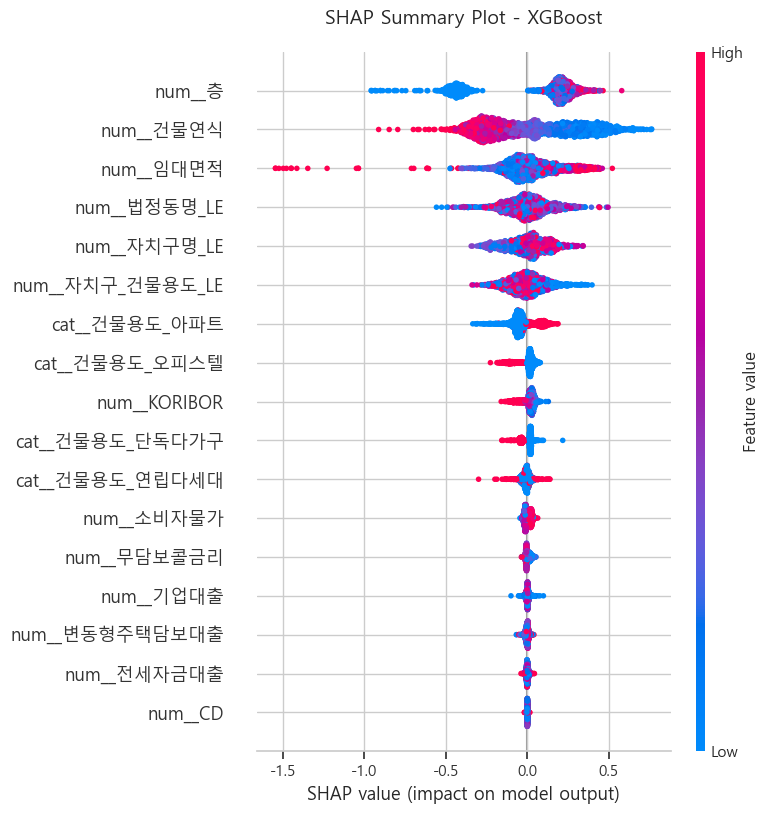

In [18]:
# ===================================
# Summary Plot - Beeswarm (피처별 영향도)
# ===================================

plt.figure(figsize=(12, 8))
shap.summary_plot(
    shap_values, 
    X_sample_trans, 
    feature_names=feature_names, 
    show=False
)
plt.title(f"SHAP Summary Plot - {best_model}", fontsize=14, pad=20)
plt.tight_layout()
plt.show()

### SHAP Bar Plot - 평균 절대 중요도
- 평균 절대 SHAP 값으로 피처 중요도 순위 표시
- 값이 클수록 모델 예측에 더 큰 영향

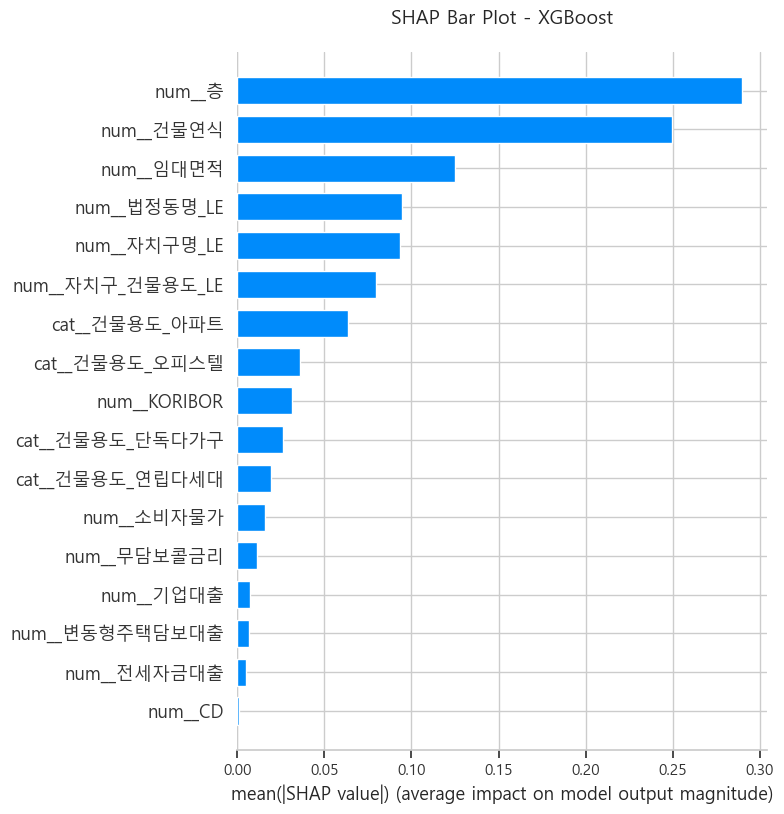

In [19]:
# ===================================
# Bar Plot - 평균 절대 SHAP 중요도
# ===================================

plt.figure(figsize=(10, 8))
shap.summary_plot(
    shap_values, 
    X_sample_trans, 
    feature_names=feature_names,
    plot_type="bar",
    show=False
)
plt.title(f"SHAP Bar Plot - {best_model}", fontsize=14, pad=20)
plt.tight_layout()
plt.show()

## 적정가 범위 시각화 (Test 데이터)
> 예측값 구간별로 오차 분포를 따로 보고, 그 구간에서의 분위수로 밴드를 잡는 방식


[잔차 퍼센트 클러스터 통계]
         count        mean           min         max
cluster                                             
2         1367 -695.946560 -11099.070755 -353.839183
1        12768 -152.813769   -353.519812  -86.981973
0        60482   10.375691    -86.964553   95.974815

[실제 데이터에서 나온 '적정' 밴드 범위]
  - 하한(5%):  -279.8%
  - 상한(95%): -90.7%


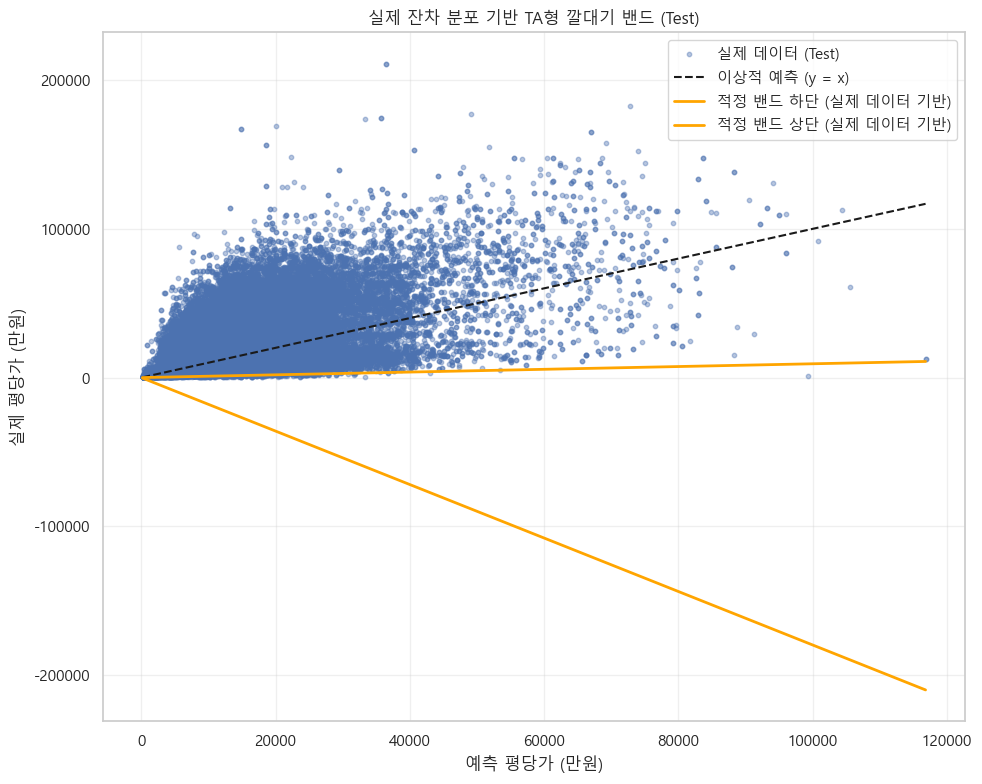

In [33]:
from sklearn.mixture import GaussianMixture
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 1) 퍼센트 잔차 데이터 (CELL 31에서 만든 error_pct 사용)
err = error_pct.dropna().values.reshape(-1, 1)

# 2) GMM으로 3개 구간 클러스터링
gmm = GaussianMixture(n_components=3, random_state=42)
gmm.fit(err)
labels = gmm.predict(err)

df_err = pd.DataFrame({
    "error_pct": error_pct.dropna().values,
    "cluster": labels
})

cluster_stats = (
    df_err
    .groupby("cluster")["error_pct"]
    .agg(["count", "mean", "min", "max"])
    .sort_values("mean")
)
print("\n[잔차 퍼센트 클러스터 통계]")
print(cluster_stats)

# 평균 기준으로 정렬된 클러스터: (낮은 평균, 중간, 높은 평균)
ordered_clusters = cluster_stats.index.tolist()
low_cluster, mid_cluster, high_cluster = ordered_clusters

# 3) '적정' 클러스터 내부에서만 5~95% 분위수로 밴드 정의
mid_errors = df_err.loc[df_err["cluster"] == mid_cluster, "error_pct"].values
band_low_pct  = np.percentile(mid_errors, 5)
band_high_pct = np.percentile(mid_errors, 95)

print(f"\n[실제 데이터에서 나온 '적정' 밴드 범위]")
print(f"  - 하한(5%):  {band_low_pct:.1f}%")
print(f"  - 상한(95%): {band_high_pct:.1f}%")

# 4) 예측 평당가에 퍼센트 밴드 적용
band_lower = y_pred_test_real * (1 + band_low_pct / 100.0)
band_upper = y_pred_test_real * (1 + band_high_pct / 100.0)

# 5) 깔대기 형태 시각화 (예측 vs 실제 + 밴드)
plt.figure(figsize=(10, 8))

plt.scatter(y_pred_test_real, y_test_real,
            s=10, alpha=0.4, label="실제 데이터 (Test)")
plt.plot([y_pred_test_real.min(), y_pred_test_real.max()],
         [y_pred_test_real.min(), y_pred_test_real.max()],
         "k--", label="이상적 예측 (y = x)")

idx_sort = np.argsort(y_pred_test_real)
x_sorted = y_pred_test_real[idx_sort]
band_lower_sorted = band_lower[idx_sort]
band_upper_sorted = band_upper[idx_sort]

plt.plot(x_sorted, band_lower_sorted,
         color="orange", linewidth=2, label="적정 밴드 하단 (실제 데이터 기반)")
plt.plot(x_sorted, band_upper_sorted,
         color="orange", linewidth=2, label="적정 밴드 상단 (실제 데이터 기반)")

plt.xlabel("예측 평당가 (만원)")
plt.ylabel("실제 평당가 (만원)")
plt.title("실제 잔차 분포 기반 TA형 깔대기 밴드 (Test)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


밴드 안에 포함된 Test 비율(coverage): 79.1%


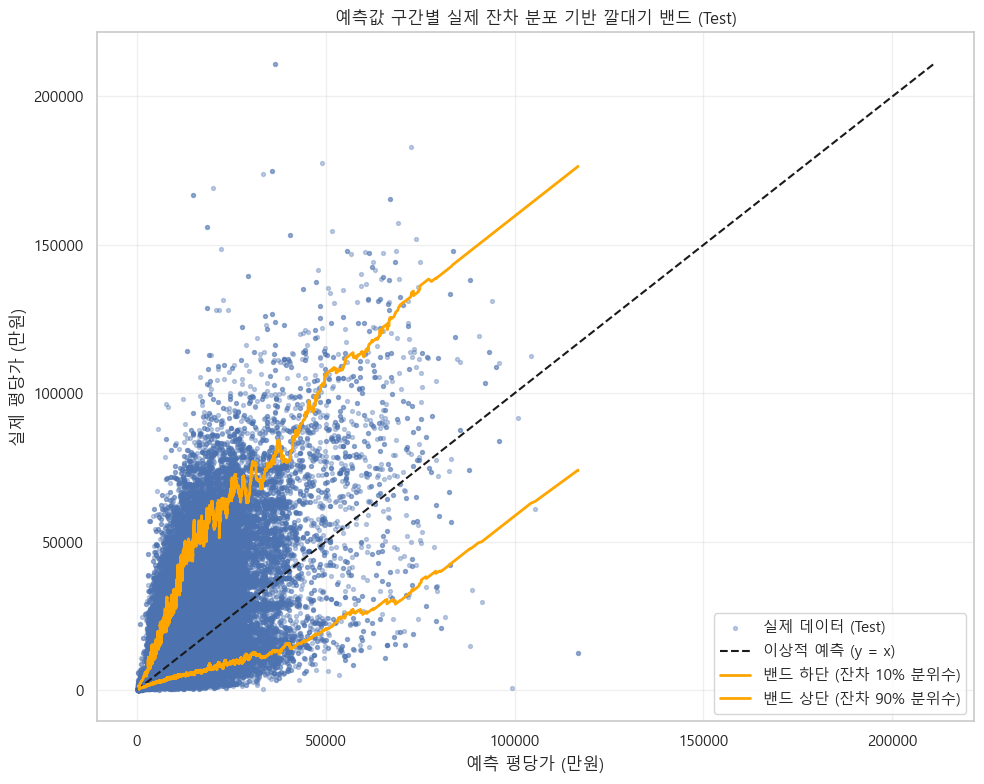

In [34]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 1) Test 예측 / 실제 / 잔차 정리
df_band = pd.DataFrame({
    "y_pred": y_pred_test_real,   # 예측 평당가 (만원)
    "y_true": y_test_real,        # 실제 평당가 (만원)
})
df_band["resid"] = df_band["y_true"] - df_band["y_pred"]

# 예측값 기준 정렬 (오른쪽으로 갈수록 비싼 물건)
df_band = df_band.sort_values("y_pred").reset_index(drop=True)

# 2) 예측값이 비슷한 구간끼리 묶어 잔차 분위수 계산 (실제 데이터 기반)
#    - window: 각 구간에 들어갈 샘플 개수 (데이터 양에 맞게 조정, 예: 300~1000)
window = 500

df_band["q_low"] = (
    df_band["resid"]
    .rolling(window, min_periods=window // 2)
    .quantile(0.10)      # 해당 구간 잔차의 10% 분위수
)
df_band["q_high"] = (
    df_band["resid"]
    .rolling(window, min_periods=window // 2)
    .quantile(0.90)      # 해당 구간 잔차의 90% 분위수
)

# 3) 예측값 기준 밴드 (절대 가격 단위)
df_band["band_lower"] = df_band["y_pred"] + df_band["q_low"]
df_band["band_upper"] = df_band["y_pred"] + df_band["q_high"]

# 부동산 가격 특성상 0 아래는 의미 없으므로 0으로 바닥 처리
df_band["band_lower"] = df_band["band_lower"].clip(lower=0)

# 4) 실제 Test 데이터가 밴드 안에 들어오는 비율(coverage) 확인
valid = df_band[["y_true", "band_lower", "band_upper"]].dropna()
coverage = ((valid["y_true"] >= valid["band_lower"]) &
            (valid["y_true"] <= valid["band_upper"])).mean()
print(f"밴드 안에 포함된 Test 비율(coverage): {coverage*100:.1f}%")

# 5) 깔대기 형태 시각화
plt.figure(figsize=(10, 8))

# 실제 데이터 산점도
plt.scatter(df_band["y_pred"], df_band["y_true"],
            s=8, alpha=0.35, label="실제 데이터 (Test)")

# 이상적 예측선 y = x
min_val = min(df_band["y_pred"].min(), df_band["y_true"].min())
max_val = max(df_band["y_pred"].max(), df_band["y_true"].max())
plt.plot([min_val, max_val], [min_val, max_val],
         "k--", label="이상적 예측 (y = x)")

# 실제 잔차 분포로부터 나온 깔대기 밴드
plt.plot(df_band["y_pred"], df_band["band_lower"],
         color="orange", linewidth=2, label="밴드 하단 (잔차 10% 분위수)")
plt.plot(df_band["y_pred"], df_band["band_upper"],
         color="orange", linewidth=2, label="밴드 상단 (잔차 90% 분위수)")

plt.xlabel("예측 평당가 (만원)")
plt.ylabel("실제 평당가 (만원)")
plt.title("예측값 구간별 실제 잔차 분포 기반 깔대기 밴드 (Test)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
